
image 1/1 D:\WEB\Python\python-ai-62\05_yolo_intro\street.jpg: 640x512 5 persons, 1 bicycle, 2 cars, 1 backpack, 3 suitcases, 1208.4ms
Speed: 20.1ms preprocess, 1208.4ms inference, 22.9ms postprocess per image at shape (1, 3, 640, 512)


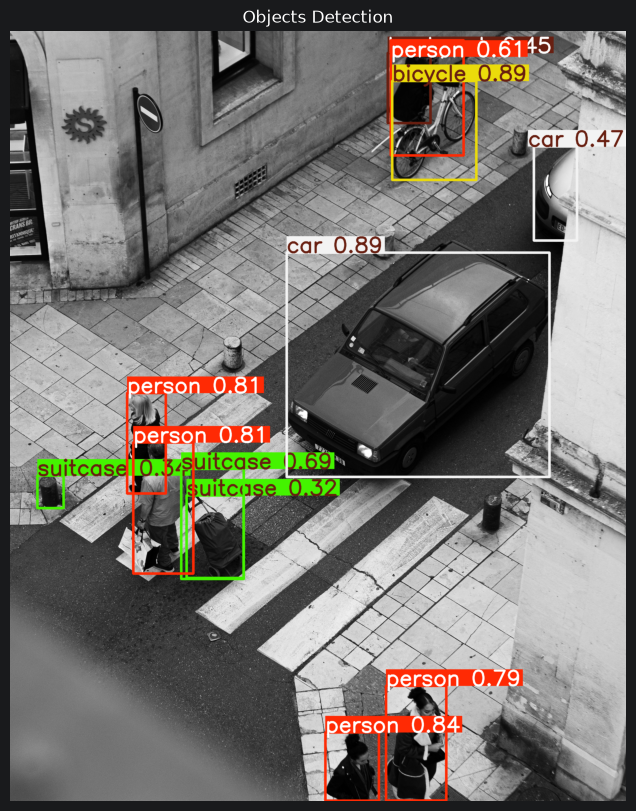

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from ultralytics import YOLO
import matplotlib.pyplot as plt
model = YOLO('yolov8m.pt')
results = model('street.jpg')
img_annotated= results[0].plot()
plt.figure(figsize=(10,10))
plt.imshow(img_annotated)
plt.title('Objects Detection')
plt.axis('off')
plt.show()


image 1/1 D:\WEB\Python\python-ai-62\05_yolo_intro\street.jpg: 640x512 5 persons, 1 bicycle, 2 cars, 1 handbag, 1 suitcase, 2366.6ms
Speed: 15.6ms preprocess, 2366.6ms inference, 74.5ms postprocess per image at shape (1, 3, 640, 512)


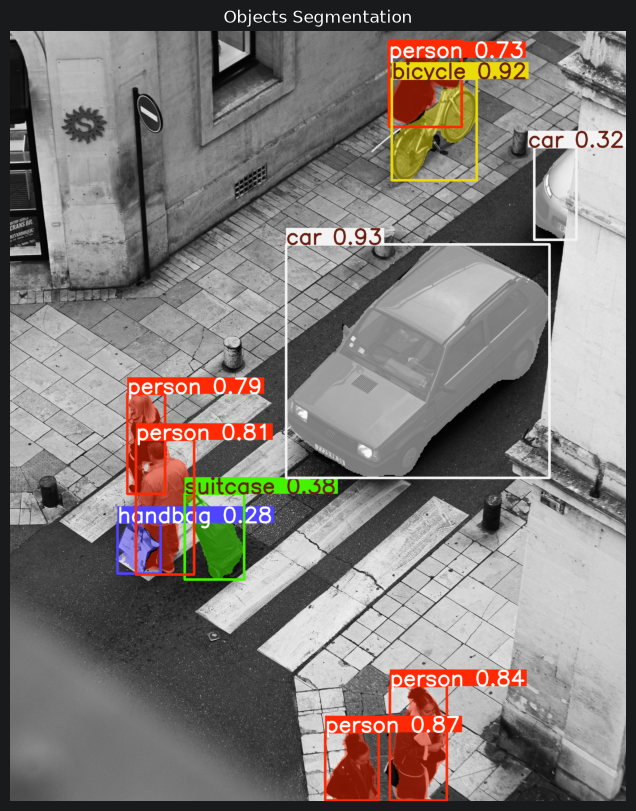

In [6]:
model = YOLO('yolov8m-seg.pt')
results = model('street.jpg')
img_annotated= results[0].plot()
plt.figure(figsize=(10,10))
plt.imshow(img_annotated)
plt.title('Objects Segmentation')
plt.axis('off')
plt.show()


image 1/1 D:\WEB\Python\python-ai-62\05_yolo_intro\street.jpg: 224x224 cab 0.40, streetcar 0.21, trolleybus 0.15, police_van 0.13, garbage_truck 0.02, 355.3ms
Speed: 104.9ms preprocess, 355.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


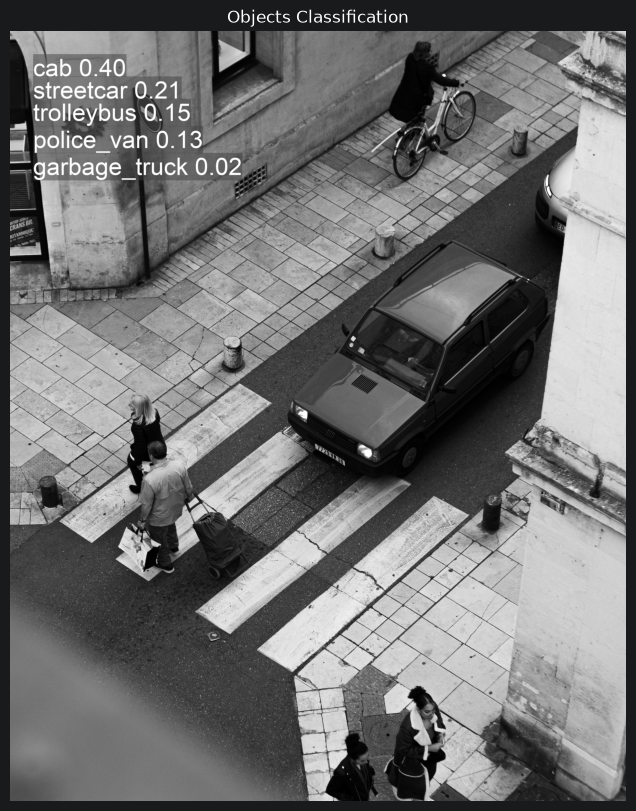

In [4]:
model = YOLO('yolov8l-cls.pt')
results = model('street.jpg')
img_annotated= results[0].plot()
plt.figure(figsize=(10,10))
plt.imshow(img_annotated)
plt.title('Objects Classification')
plt.axis('off')
plt.show()

In [7]:
model = YOLO('yolov8m.pt')
results = model('street.jpg')
boxes = results[0].boxes
xyxy=boxes.xyxy.cpu().numpy()
xyxy


image 1/1 D:\WEB\Python\python-ai-62\05_yolo_intro\street.jpg: 640x512 5 persons, 1 bicycle, 2 cars, 1 backpack, 3 suitcases, 1413.2ms
Speed: 8.1ms preprocess, 1413.2ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 512)


array([[     1437.5,      1151.3,      2802.4,        2317],
       [     1985.2,      259.94,      2422.6,      773.97],
       [       1638,      3643.4,      1916.4,      3998.1],
       [     640.25,      2137.8,      952.16,      2818.5],
       [     608.25,      1880.8,      809.45,      2402.9],
       [     1953.4,      3401.3,        2266,      3997.4],
       [     889.21,      2274.6,      1214.6,      2846.7],
       [       1978,      48.685,      2356.9,      646.78],
       [     2721.7,      599.73,        2945,      1088.3],
       [     1962.5,      114.74,      2184.2,      478.56],
       [     142.47,      2309.4,       278.6,      2478.4],
       [     917.78,      2412.4,        1214,      2841.5]], dtype=float32)

In [8]:
classes = boxes.cls.cpu().numpy()
classes

array([          2,           1,           0,           0,           0,           0,          28,           0,           2,          24,          28,          28], dtype=float32)

In [9]:
all_names = results[0].names
all_names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [10]:
names = [all_names[i] for i in classes]
names

['car',
 'bicycle',
 'person',
 'person',
 'person',
 'person',
 'suitcase',
 'person',
 'car',
 'backpack',
 'suitcase',
 'suitcase']

In [11]:
confidence_arr = boxes.conf.cpu().numpy()
confidence_arr

array([    0.89161,     0.88988,     0.84173,     0.81305,     0.80561,     0.78545,     0.68597,     0.60962,     0.46573,     0.45042,      0.3427,     0.31575], dtype=float32)

In [12]:
from pandas import DataFrame
df = DataFrame(xyxy,columns=['xmin', 'ymin','xmax','ymax'])
df

,xmin,ymin,xmax,ymax
0,1437.517090,1151.334717,2802.376221,2316.987305
1,1985.165771,259.942657,2422.573486,773.970642
2,1638.027222,3643.390625,1916.421509,3998.137695
3,640.245728,2137.760986,952.158386,2818.450195
4,608.245300,1880.795532,809.451477,2402.937500
5,1953.442749,3401.306885,2266.012207,3997.412842
6,889.206360,2274.583984,1214.602661,2846.696289
7,1978.030273,48.684692,2356.857422,646.779541
8,2721.663330,599.732117,2945.041016,1088.339355
9,1962.484009,114.744431,2184.171387,478.557678


In [13]:
df['names'] = names
df

,xmin,ymin,xmax,ymax,names
0,1437.517090,1151.334717,2802.376221,2316.987305,car
1,1985.165771,259.942657,2422.573486,773.970642,bicycle
2,1638.027222,3643.390625,1916.421509,3998.137695,person
3,640.245728,2137.760986,952.158386,2818.450195,person
4,608.245300,1880.795532,809.451477,2402.937500,person
5,1953.442749,3401.306885,2266.012207,3997.412842,person
6,889.206360,2274.583984,1214.602661,2846.696289,suitcase
7,1978.030273,48.684692,2356.857422,646.779541,person
8,2721.663330,599.732117,2945.041016,1088.339355,car
9,1962.484009,114.744431,2184.171387,478.557678,backpack


In [14]:
df['confidence']= confidence_arr
df

,xmin,ymin,xmax,ymax,names,confidence
0,1437.517090,1151.334717,2802.376221,2316.987305,car,0.891611
1,1985.165771,259.942657,2422.573486,773.970642,bicycle,0.889878
2,1638.027222,3643.390625,1916.421509,3998.137695,person,0.841732
3,640.245728,2137.760986,952.158386,2818.450195,person,0.813046
4,608.245300,1880.795532,809.451477,2402.937500,person,0.805607
5,1953.442749,3401.306885,2266.012207,3997.412842,person,0.785446
6,889.206360,2274.583984,1214.602661,2846.696289,suitcase,0.685975
7,1978.030273,48.684692,2356.857422,646.779541,person,0.609619
8,2721.663330,599.732117,2945.041016,1088.339355,car,0.465731
9,1962.484009,114.744431,2184.171387,478.557678,backpack,0.450415
